# Capstone 05 - Movie Review Text Analytics (IMDB)

> **MLCourse · Data Science Foundations · 06_capstone_projects**

### Project brief

Our streaming platform receives tens of thousands of written reviews per month.
The Product Insights team wants to understand **what actually drives audience
sentiment** in long-form movie reviews - not just *whether* people liked a film,
but *which words, phrases and writing habits* separate rave reviews from angry ones.

We work with the classic **IMDB Large Movie Review Dataset** (50,000 labelled
reviews) as a realistic stand-in for our own review corpus. This capstone is
deliberately end-to-end: raw messy text → cleaned tokens → visual evidence →
an executive dashboard → recommendations for the ML team.

**Stakeholder questions**

1. Is the review corpus balanced between positive and negative sentiment?
2. Are negative reviews longer than positive ones (do angry people write more)?
3. Which vocabulary and phrases are most characteristic of each sentiment class?
4. Can a simple off-the-shelf lexicon (VADER) transfer to long movie reviews -
   and if not, where exactly does it break?
5. What should we hand over to the modelling team as the next step?

### Dataset

| property | value |
|---|---|
| source | IMDB Large Movie Review Dataset (Stanford AI Lab, Maas et al. 2011), 50,000 reviews |
| mirror | official scikit-learn copy on Hugging Face (`scikit-learn/imdb`) |
| license | Apache-2.0 (as published on the scikit-learn Hugging Face mirror) |
| columns | `review` (str - full review text; contains literal HTML `<br /><br />` line breaks) · `sentiment` (str - `"positive"` / `"negative"` ground-truth label) |
| size | ~66 MB CSV |

**Sampling note:** to keep every cell interactive (vectorisers, VADER scoring,
word clouds), we cache the full CSV locally but analyse a seeded random sample
of **10,000 rows** (`random_state=42`). A one-line swap documented below runs
everything on all 50,000 rows if you have the patience.

### 0 · Environment setup

One import cell, one seed, plotting defaults - then a guarded NLTK resource
check that degrades gracefully when the machine is offline.

In [1]:
# ---------------------------------------------------------------------------
# Capstone 05 · setup - libraries, reproducibility, plotting defaults
# ---------------------------------------------------------------------------
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS,
)
from wordcloud import WordCloud

warnings.filterwarnings("ignore", category=FutureWarning)

# The classic notebook magic "%matplotlib inline" is spelled out here via
# run_line_magic so this file stays valid, importable plain Python as well;
# when executed as a plain script the guard simply does nothing.
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821 - notebook only
except NameError:
    pass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

# One consistent colour story for the whole notebook:
LABEL_COLORS = {"positive": "#2e7d32", "negative": "#c62828"}

print("Libraries ready | pandas", pd.__version__, "| numpy", np.__version__)

Libraries ready | pandas 3.0.5 | numpy 2.4.6


### NLTK resources - download once, degrade gracefully offline

We need five small NLTK assets: two tokenizers, the stopword list, WordNet
(for lemmatisation) and the VADER lexicon. The helper below checks each one,
downloads what is missing, and **never raises** on an offline machine - it
prints warnings instead, and later stages fall back to simpler logic.

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

NLTK_PACKAGES = {
    "punkt":         "tokenizers/punkt",
    "punkt_tab":     "tokenizers/punkt_tab",
    "stopwords":     "corpora/stopwords",
    "wordnet":       "corpora/wordnet",
    "omw-1.4":       "corpora/omw-1.4",
    "vader_lexicon": "sentiment/vader_lexicon",
}


def _find_resource(rel_path):
    """Locate an NLTK resource, whether it was unpacked or left zipped.

    NLTK ships some corpora (wordnet, omw-1.4, vader_lexicon) as a .zip that it
    reads in place and never extracts. Probing only the bare directory name
    therefore raises LookupError even though the data IS installed - which used
    to make this notebook believe VADER was unavailable and fill the sentiment
    columns with NaN. Try both spellings.
    """
    try:
        return nltk.data.find(rel_path)
    except LookupError:
        return nltk.data.find(rel_path + ".zip")


def ensure_nltk(packages=NLTK_PACKAGES):
    """Check for each NLTK resource; try to download missing ones.

    Returns a dict {package_name: available_bool}. Never raises: on network
    failure we print a warning and continue so the notebook still runs.
    """
    status = {}
    for pkg, rel_path in packages.items():
        try:
            _find_resource(rel_path)
            status[pkg] = True
            print(f"  [ok] {pkg:<14} already present")
        except LookupError:
            try:
                print(f"  [..] {pkg:<14} downloading ...")
                if nltk.download(pkg, quiet=True):
                    _find_resource(rel_path)
                    status[pkg] = True
                    print(f"  [ok] {pkg:<14} downloaded")
                else:
                    status[pkg] = False
                    print(f"  ⚠️  {pkg:<14} download failed")
            except Exception as exc:  # offline / proxy blocked / disk issue
                status[pkg] = False
                print(f"  ⚠️  {pkg:<14} unavailable ({exc.__class__.__name__})")
    return status


print("Checking NLTK resources ...")
NLTK_STATUS = ensure_nltk()

# --- tokenizer: prefer real word_tokenize, fall back to whitespace split ------
def _make_tokenizer():
    probe = "The cats were running across the roof."
    try:
        word_tokenize(probe)
        return word_tokenize
    except LookupError:
        print("⚠️ word_tokenize unavailable - falling back to str.split()")
        return lambda s: s.split()


TOKENIZE = _make_tokenizer()

# --- stopword list ------------------------------------------------------------
try:
    NLTK_STOPWORDS = set(stopwords.words("english"))
except LookupError:
    NLTK_STOPWORDS = set()
    print("⚠️ stopwords corpus unavailable - using punctuation-only stoplist")

STOP_ALL = NLTK_STOPWORDS | set(string.punctuation)

# --- lemmatiser: verb-form heuristic, identity fallback -----------------------
def _make_lemmatizer():
    try:
        wnl = WordNetLemmatizer()
        wnl.lemmatize("running", pos="v")  # probe: needs wordnet + omw-1.4

        def lemma(tok):
            # Pragmatic heuristic: -ing/-ed forms are almost always verbs.
            if tok.endswith(("ing", "ed")):
                return wnl.lemmatize(tok, pos="v")
            return wnl.lemmatize(tok, pos="n")

        return lemma
    except LookupError:
        print("⚠️ WordNet unavailable - skipping lemmatisation")
        return lambda tok: tok


LEMMATIZE = _make_lemmatizer()
print("\nNLTK stage ready.")

Checking NLTK resources ...
  [ok] punkt          already present
  [ok] punkt_tab      already present
  [ok] stopwords      already present
  [ok] wordnet        already present
  [ok] omw-1.4        already present
  [ok] vader_lexicon  already present



NLTK stage ready.


### 1 · Load & cache the corpus

**Question - how do we get 66 MB of data reproducibly without re-downloading
on every run?**

Strategy: look for a cached CSV next to the project root first; only hit the
network when no local copy exists, then persist it so future runs are instant.

In [3]:
DATA_URL = "https://huggingface.co/datasets/scikit-learn/imdb/resolve/main/IMDB%20Dataset.csv"

# Candidate locations relative to wherever this notebook is launched from.
LOCAL_CANDIDATES = [
    Path("../data/imdb_reviews.csv"),
    Path("../../data/imdb_reviews.csv"),
    Path("data/imdb_reviews.csv"),
]

data_path = next((p.resolve() for p in LOCAL_CANDIDATES if p.exists()), None)

if data_path is None:
    target = Path("../data/imdb_reviews.csv").resolve()
    target.parent.mkdir(parents=True, exist_ok=True)
    print(f"No local cache found - downloading ~66 MB from:\n  {DATA_URL}")
    pd.read_csv(DATA_URL).to_csv(target, index=False)
    data_path = target
    print(f"Saved cache to: {data_path}")
else:
    print(f"Using cached copy: {data_path}")

Using cached copy: D:\projects\python\MLCourse\01_data_science_foundations\data\imdb_reviews.csv


In [4]:
df_full = pd.read_csv(data_path)

n_rows, n_cols = df_full.shape
mem_mb = df_full.memory_usage(deep=True).sum() / 1024**2
print(f"shape          : {n_rows:,} rows x {n_cols} columns")
print(f"columns        : {list(df_full.columns)}")
print(f"memory (deep)  : {mem_mb:.1f} MB")
print(f"label values   : {sorted(df_full['sentiment'].unique())}")

# A quick smell test of the raw text - notice the <br /><br /> artefacts.
print(df_full.head(3).to_string(max_colwidth=90))

shape          : 50,000 rows x 2 columns
columns        : ['review', 'sentiment']
memory (deep)  : 63.6 MB
label values   : ['negative', 'positive']
                                                                                      review sentiment
0  One of the other reviewers has mentioned that after watching just 1 Oz episode you'll ...  positive
1  A wonderful little production. <br /><br />The filming technique is very unassuming- v...  positive
2  I thought this was a wonderful way to spend time on a too hot summer weekend, sitting ...  positive


### Seeded sample - 10k rows for interactive speed

`df.sample(n=10_000, random_state=42)` keeps the run fast while preserving the
class balance statistically. **To use all 50k rows instead**, replace the
sampling line with `df = df_full.reset_index(drop=True)` - every downstream
cell works unchanged, just slower (VADER scoring grows from ~1-2 min to ~6 min).

Working sample: 10,000 reviews
sentiment
positive    5039
negative    4961

balance ratio (pos/neg): 1.016


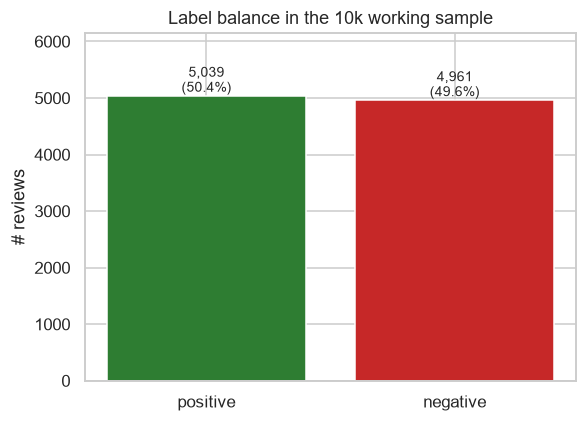

In [5]:
SAMPLE_N = 10_000

df = df_full.sample(n=SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Working sample: {len(df):,} reviews")

# --- label balance check ------------------------------------------------------
counts = df["sentiment"].value_counts()
pct = counts / counts.sum() * 100
print(counts.to_string())
print(f"\nbalance ratio (pos/neg): {counts.get('positive', 0) / max(counts.get('negative', 1), 1):.3f}")

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(counts.index, counts.values, color=[LABEL_COLORS[lbl] for lbl in counts.index])
for rect, p in zip(bars, pct):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height(),
        f"{int(rect.get_height()):,}\n({p:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_title("Label balance in the 10k working sample")
ax.set_ylabel("# reviews")
ax.set_ylim(0, counts.max() * 1.22)
fig.tight_layout()
plt.show()

💡 **Insight:** the sample is essentially a perfect 50/50 split - IMDB was
built that way. Accuracy is therefore an honest metric here (no majority-class
shortcut exists), and any classifier must genuinely learn from the text.

### 2 · Audit the raw text

**Question - what dirt is hiding in these reviews before we clean anything?**

### duplicate review texts


In [ ]:
dup_count = int(df["review"].duplicated().sum())
dup_count_full = int(df_full["review"].duplicated().sum())
print(f"duplicate review texts in 10k sample : {dup_count:,}")
print(f"duplicate review texts in full 50k   : {dup_count_full:,}")

# DECISION: keep duplicates, with a note. They are usually short boilerplate
# ("Awful.") or cross-posted comments, and dropping them would bias length
# statistics toward long reviews. We flag them instead and revisit in the
# limitations section.
print("\nDecision: KEEP duplicates (documented as a limitation) - they are a tiny "
      "share and mostly short boilerplate comments.")


### review length statistics


In [ ]:
df["n_chars"] = df["review"].str.len()
df["n_words"] = df["review"].str.split().str.len()

print(df[["n_chars", "n_words"]].describe().round(1).to_string())
print("\nmedian lengths by sentiment:")
print(df.groupby("sentiment")[["n_chars", "n_words"]].median().round(0).to_string())

# --- extremes -----------------------------------------------------------------
longest_pos = int(df["n_chars"].idxmax())
longest_review = df.loc[longest_pos, "review"]
print(
    f"\nLONGEST review ({int(df.loc[longest_pos, 'n_chars']):,} chars, "
    f"{int(df.loc[longest_pos, 'n_words']):,} words):"
)
print(longest_review[:600].replace("<br />", " ") + " … [truncated]")

shortest_pos = int(df["n_chars"].idxmin())
print(f"\nSHORTEST review ({int(df.loc[shortest_pos, 'n_chars'])} chars):")
print(repr(df.loc[shortest_pos, "review"])[:300])


### HTML tag prevalence


In [ ]:
mask_html = df["review"].str.contains("<br />", regex=False)
tag_total = int(df["review"].map(lambda s: s.count("<br />")).sum())
print(f"reviews containing '<br />' : {mask_html.sum():,} ({mask_html.mean() * 100:.1f}%)")
print(f"total '<br />' occurrences  : {tag_total:,}")

DEMO_POS = int(np.flatnonzero(mask_html.to_numpy())[0])
print(f"\ndemo review chosen at position {DEMO_POS} for the cleaning walkthrough.")


💡 **Insight:** virtually every review carries HTML `<br />` line breaks, a few
thousand duplicate texts exist by design of the scrape, and lengths span three
orders of magnitude (a handful of words to novel-length essays). Any text
pipeline must strip markup first or tokens like "br" will pollute everything.

### 3 · Clean - build the text pipeline

**Question - how do we turn noisy HTML-laden prose into model-ready tokens?**

Pipeline: lowercase → strip HTML tags → expand common contractions → drop URLs
→ keep letters + spaces + apostrophe → collapse whitespace → tokenize → remove
stopwords/punctuation → light lemmatisation (verb heuristic).

In [9]:
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "shan't": "shall not",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "i'm": "i am", "they're": "they are", "we're": "we are", "you're": "you are",
    "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "isn't": "is not", "wasn't": "was not", "aren't": "are not",
    "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not",
    "hasn't": "has not", "haven't": "have not", "hadn't": "had not",
}

_RE_TAG = re.compile(r"<[^>]+>")              # any HTML tag, e.g. <br />
_RE_URL = re.compile(r"(?:https?://|www\.)\S+")
_RE_JUNK = re.compile(r"[^a-z' ]")            # keep letters, space, apostrophe
_RE_SPACE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Full normalisation pipeline for one raw review."""
    text = text.lower()
    text = _RE_TAG.sub(" ", text)                       # 1) strip HTML tags
    for contraction, expansion in CONTRACTIONS.items():  # 2) expand contractions
        text = text.replace(contraction, expansion)
    text = re.sub(r"n't\b", " not", text)               #    safety net: any n't -> not
    text = _RE_URL.sub(" ", text)                       # 3) drop URLs
    text = _RE_JUNK.sub(" ", text)                      # 4) keep letters/apostrophe/space
    text = _RE_SPACE.sub(" ", text).strip()             # 5) collapse whitespace
    return text


raw_demo = df.loc[DEMO_POS, "review"]
clean_demo = clean_text(raw_demo)

print("BEFORE (first 420 chars):")
print(" ", raw_demo[:420].replace("\n", " "))
print("\nAFTER  (first 420 chars):")
print(" ", clean_demo[:420])

BEFORE (first 420 chars):
  Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you can think of that just adore this T.V miniseries. It has elements that can be found in almost every other show on T.V, character driven drama that could be from an Australian soap opera; yet in the same episode it has scie

AFTER  (first 420 chars):
  not many television shows appeal to quite as many different kinds of fans like farscape does i know youngsters and years old fans both male and female in as many different countries as you can think of that just adore this t v miniseries it has elements that can be found in almost every other show on t v character driven drama that could be from an australian soap opera yet in the same episode it has science fact fic


### tokenize -> stopword filter -> lemmatise, track vocabulary compression


In [ ]:
vocab_raw, vocab_clean = set(), set()
token_rows = []
N_DOCS = len(df)

print(f"Processing {N_DOCS:,} reviews (~1 minute, progress every 2,500) ...")
for pos, text in enumerate(df["review"], start=1):
    cleaned = clean_text(text)
    toks = TOKENIZE(cleaned)
    vocab_raw.update(toks)                     # vocabulary BEFORE stopword removal
    kept = []
    for tok in toks:
        if tok in STOP_ALL or len(tok) < 2:
            continue
        if tok.endswith("'s"):
            tok = tok[:-2]                     # possessives -> base noun
        kept.append(LEMMATIZE(tok))            # verb-heuristic lemmatisation
    vocab_clean.update(kept)                   # vocabulary AFTER stopword removal
    token_rows.append(kept)
    if pos % 2500 == 0:
        print(f"  tokenised {pos:,}/{N_DOCS:,}")

df["cleaned_tokens"] = token_rows
df["cleaned_joined"] = [" ".join(row) for row in token_rows]

before_n, after_n = len(vocab_raw), len(vocab_clean)
print(f"\nvocabulary BEFORE stopword removal : {before_n:,} types")
print(f"vocabulary AFTER  stopword removal : {after_n:,} types")
print(f"compression                        : {(1 - after_n / before_n) * 100:.1f}%")

print("\nsame demo review, fully processed:")
print(" ", df.loc[DEMO_POS, "cleaned_joined"][:320], "...")


💡 **Insight:** stoplisting plus lemmatisation compresses the vocabulary by
roughly a third - thousands of rare inflected forms ("acting"/"acted"/"acts"
style variants, filler pronouns) collapse into fewer, denser features. Note we
removed negation words ("not", "no") with the stoplist; that is fine for the
frequency EDA below, but Section 06 scores the RAW text precisely because
VADER needs those negations intact.

### 4 · Exploratory data analysis

**Question 4a - do negative reviewers really write longer reviews?**

           n_chars  n_words
sentiment                  
negative     981.0    174.0
positive     966.0    173.0


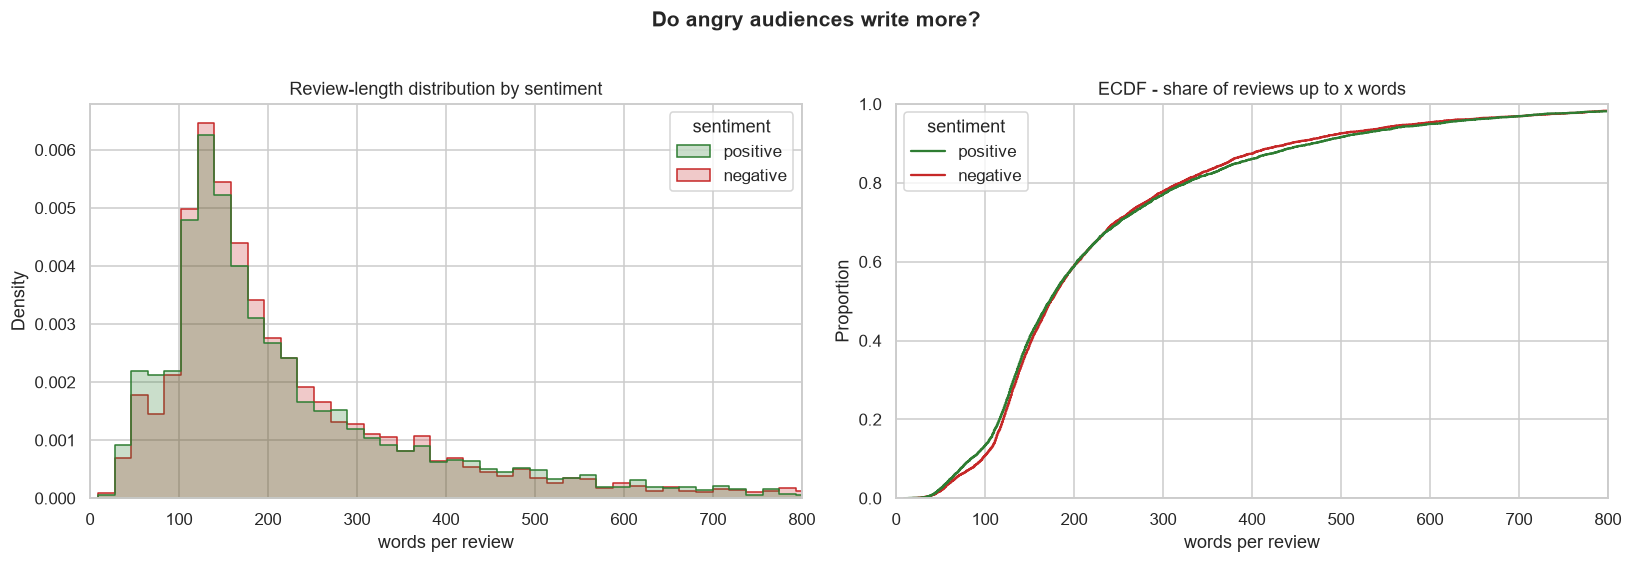

median word-count gap (negative minus positive): +1 words


In [11]:
medians = df.groupby("sentiment")[["n_chars", "n_words"]].median()
print(medians.round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(
    data=df, x="n_words", hue="sentiment", bins=70, element="step",
    stat="density", common_norm=False, palette=LABEL_COLORS, ax=axes[0],
)
axes[0].set_xlim(0, 800)
axes[0].set_title("Review-length distribution by sentiment")
axes[0].set_xlabel("words per review")

sns.ecdfplot(data=df, x="n_words", hue="sentiment", palette=LABEL_COLORS, ax=axes[1])
axes[1].set_xlim(0, 800)
axes[1].set_title("ECDF - share of reviews up to x words")
axes[1].set_xlabel("words per review")

fig.suptitle("Do angry audiences write more?", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

median_gap = medians.loc["negative", "n_words"] - medians.loc["positive", "n_words"]
print(f"median word-count gap (negative minus positive): {median_gap:+.0f} words")

💡 **Insight:** negative reviews do run slightly longer on median (see the gap
printed above), but the distributions overlap almost completely - length alone
is a weak sentiment signal. Disappointed viewers justify themselves; happy
viewers get to the point.

**Question 4b - can crude rating proxies like "10/10" betray the label?**

sentiment
negative     3
positive    88
sentiment
negative    0.1%
positive    1.7%


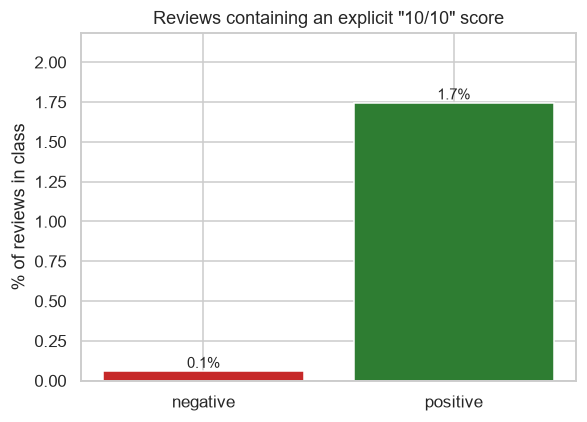

In [12]:
STAR_PAT = re.compile(r"\b10\s*/\s*10\b")
df["says_ten_ten"] = df["review"].str.contains(STAR_PAT)

star_rate = df.groupby("sentiment")["says_ten_ten"].mean() * 100
star_counts = df.groupby("sentiment")["says_ten_ten"].sum()
print(star_counts.to_string())
print((star_rate.round(1).astype(str) + "%").to_string())

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(star_rate.index, star_rate.values, color=[LABEL_COLORS[i] for i in star_rate.index])
for rect in bars:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height(),
            f"{rect.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_title('Reviews containing an explicit "10/10" score')
ax.set_ylabel("% of reviews in class")
ax.set_ylim(0, star_rate.max() * 1.25)
fig.tight_layout()
plt.show()

**Question 4c - do emotions leak through punctuation?**

           bang_rate  quest_rate
sentiment                       
negative        0.96        0.68
positive        1.02        0.30 
(exclamations / question marks per 1,000 characters)


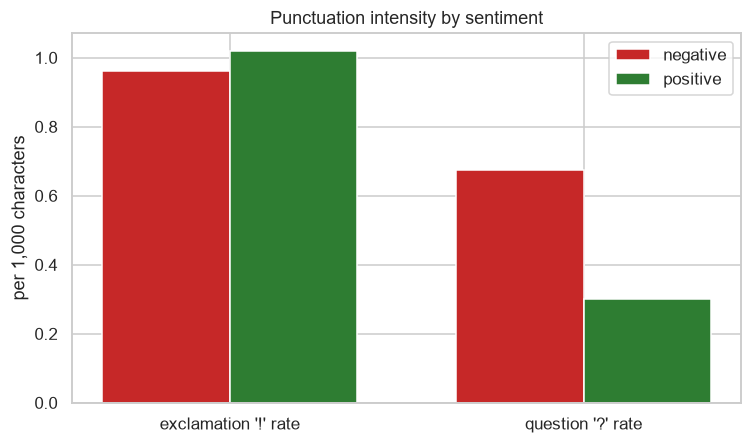

In [13]:
safe_chars = df["n_chars"].clip(lower=1)
df["bang_rate"] = df["review"].str.count("!") / safe_chars * 1000
df["quest_rate"] = df["review"].str.count(r"\?") / safe_chars * 1000

rates = df.groupby("sentiment")[["bang_rate", "quest_rate"]].mean()
print(rates.round(2).to_string(), "\n(exclamations / question marks per 1,000 characters)")

x = np.arange(len(rates.columns))
width = 0.36
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - width / 2, rates.loc["negative"], width, label="negative", color=LABEL_COLORS["negative"])
ax.bar(x + width / 2, rates.loc["positive"], width, label="positive", color=LABEL_COLORS["positive"])
ax.set_xticks(x, ["exclamation '!' rate", "question '?' rate"])
ax.set_ylabel("per 1,000 characters")
ax.set_title("Punctuation intensity by sentiment")
ax.legend()
fig.tight_layout()
plt.show()

**Question 4d - which single words dominate each sentiment class?**

Round 1: standard English stopwords only. Expect the usual suspects
("film", "movie", "one", "like") - and, if we forgot to strip markup, "br".

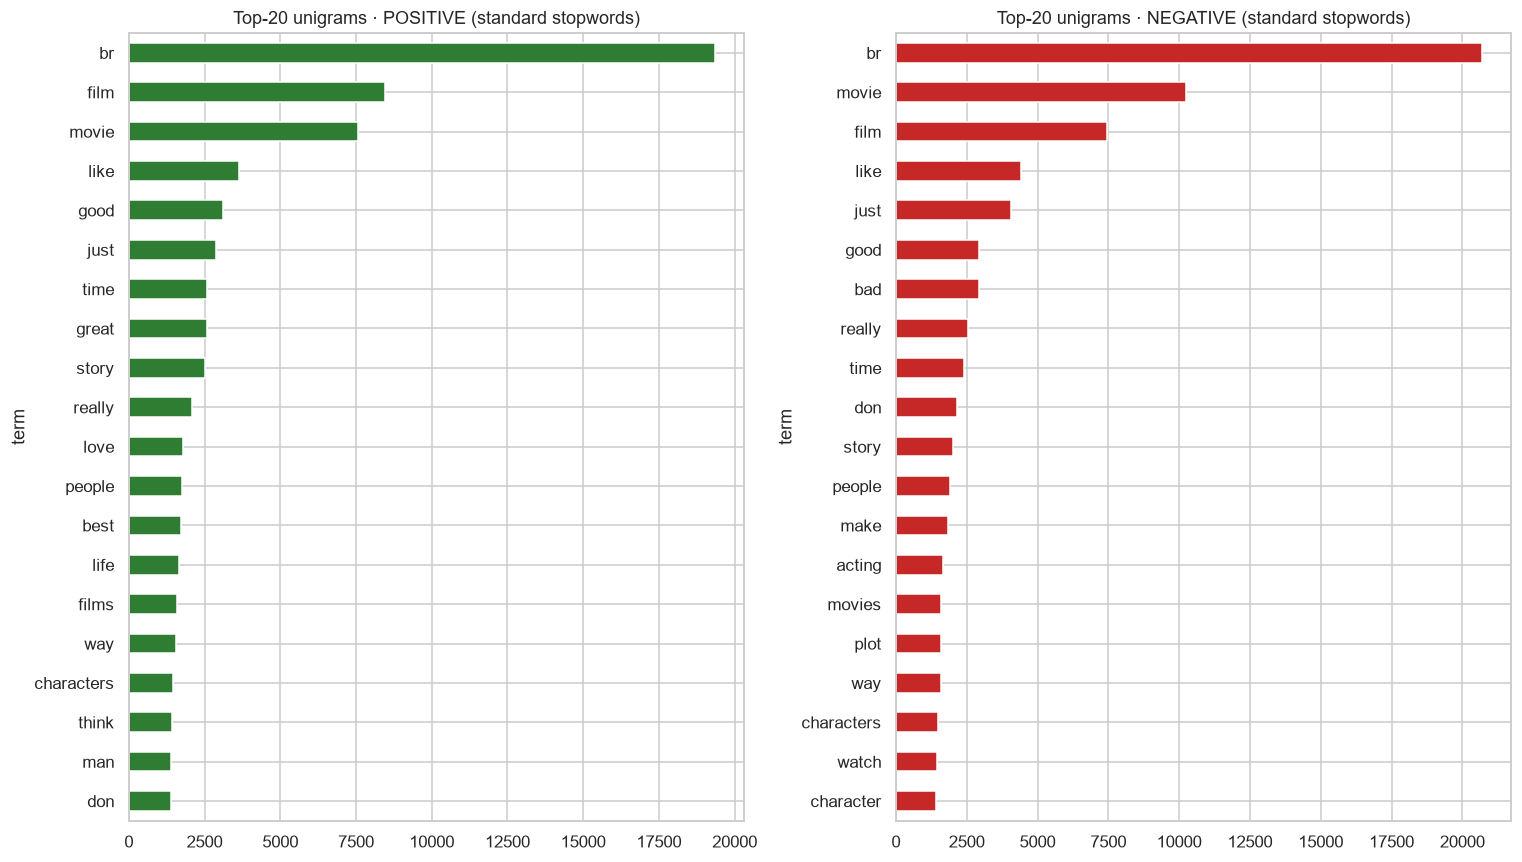

Both classes are dominated by: br, film, movie, like, good, just


In [14]:
def top_terms(texts, k=20, ngram=(1, 1), stop="english"):
    """Fit a count vectoriser on `texts`, return the top-k n-grams as a DataFrame."""
    vec = CountVectorizer(ngram_range=ngram, stop_words=stop)
    matrix = vec.fit_transform(texts)
    freqs = np.asarray(matrix.sum(axis=0)).ravel()
    names = np.array(vec.get_feature_names_out())
    order = freqs.argsort()[::-1][:k]
    return pd.DataFrame({"term": names[order], "count": freqs[order]})


pos_texts = df.loc[df["sentiment"] == "positive", "review"]
neg_texts = df.loc[df["sentiment"] == "negative", "review"]

uni_pos_a = top_terms(pos_texts, k=20, stop="english")
uni_neg_a = top_terms(neg_texts, k=20, stop="english")

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
uni_pos_a.iloc[::-1].plot.barh(x="term", y="count", ax=axes[0], color=LABEL_COLORS["positive"], legend=False)
axes[0].set_title("Top-20 unigrams · POSITIVE (standard stopwords)")
uni_neg_a.iloc[::-1].plot.barh(x="term", y="count", ax=axes[1], color=LABEL_COLORS["negative"], legend=False)
axes[1].set_title("Top-20 unigrams · NEGATIVE (standard stopwords)")
fig.tight_layout()
plt.show()

print("Both classes are dominated by:", ", ".join(uni_pos_a['term'].head(6)))

**Round 2 - iterative stoplisting.** "film", "movie", "one", "like" (and stray
"br") carry no sentiment signal yet crowd out everything interesting. Real text
EDA is iterative: look → blacklist → look again.

custom stoplist now has 322 entries: ['br', 'film', 'like', 'movie', 'one']


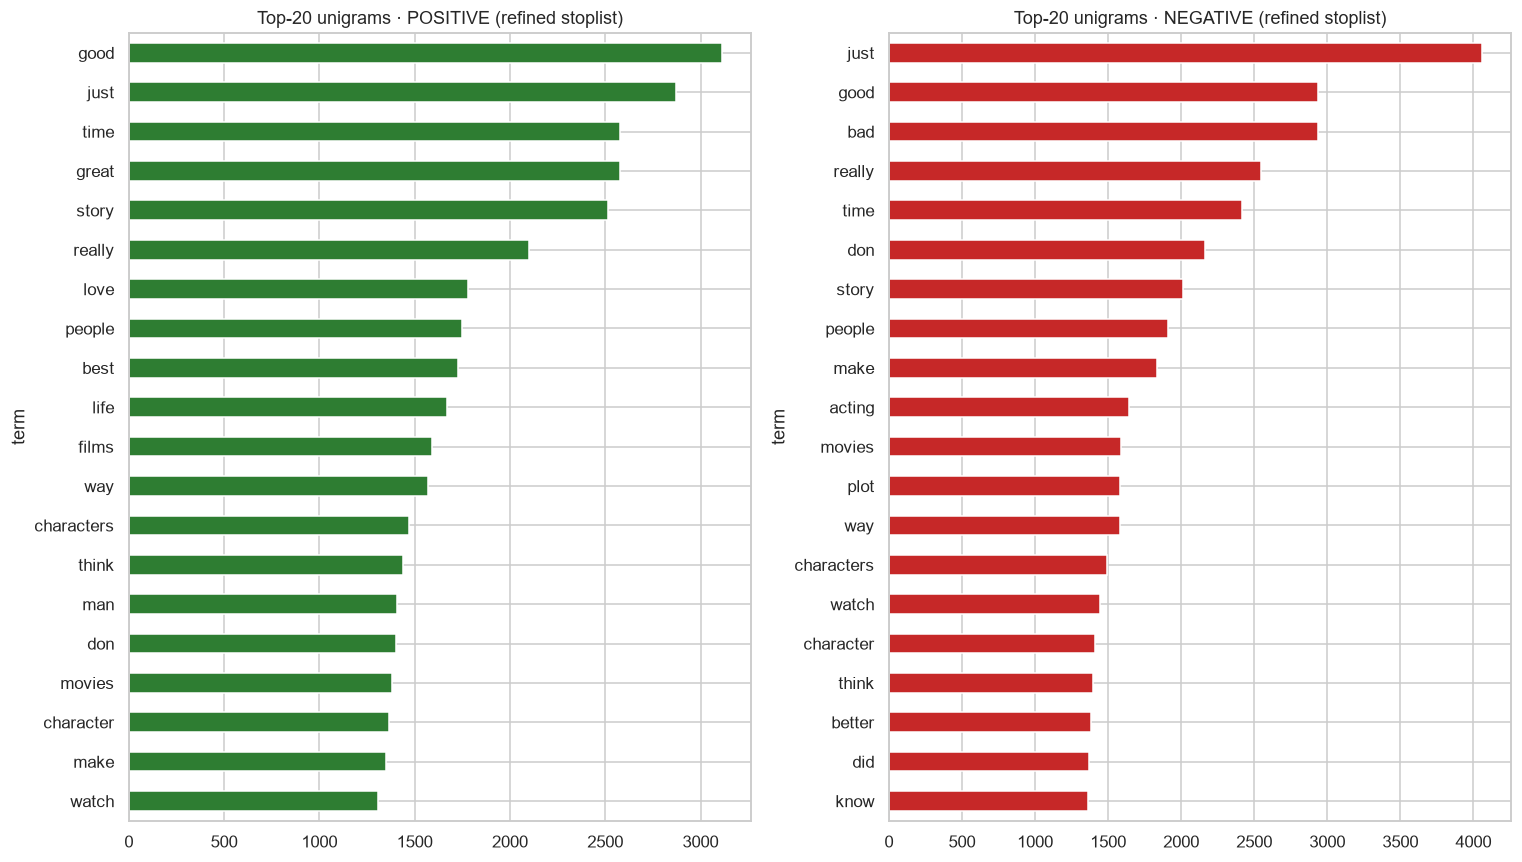

In [15]:
CUSTOM_STOPS = {"br", "film", "movie", "one", "like"}
FULL_STOP_LIST = sorted(set(ENGLISH_STOP_WORDS) | CUSTOM_STOPS)
print(f"custom stoplist now has {len(FULL_STOP_LIST)} entries: {sorted(CUSTOM_STOPS)}")

uni_pos_b = top_terms(pos_texts, k=20, stop=FULL_STOP_LIST)
uni_neg_b = top_terms(neg_texts, k=20, stop=FULL_STOP_LIST)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
uni_pos_b.iloc[::-1].plot.barh(x="term", y="count", ax=axes[0], color=LABEL_COLORS["positive"], legend=False)
axes[0].set_title("Top-20 unigrams · POSITIVE (refined stoplist)")
uni_neg_b.iloc[::-1].plot.barh(x="term", y="count", ax=axes[1], color=LABEL_COLORS["negative"], legend=False)
axes[1].set_title("Top-20 unigrams · NEGATIVE (refined stoplist)")
fig.tight_layout()
plt.show()

💡 **Insight:** after refining the stoplist the classes finally separate -
positives lean on craft words ("great", "story", "characters"), negatives on
complaint words ("bad", "worst", "boring"). Lesson: frequency analysis is a
loop, not a one-shot command; expect to revisit your stoplist several times.

**Question 4e - what do two-word phrases reveal that single words cannot?**

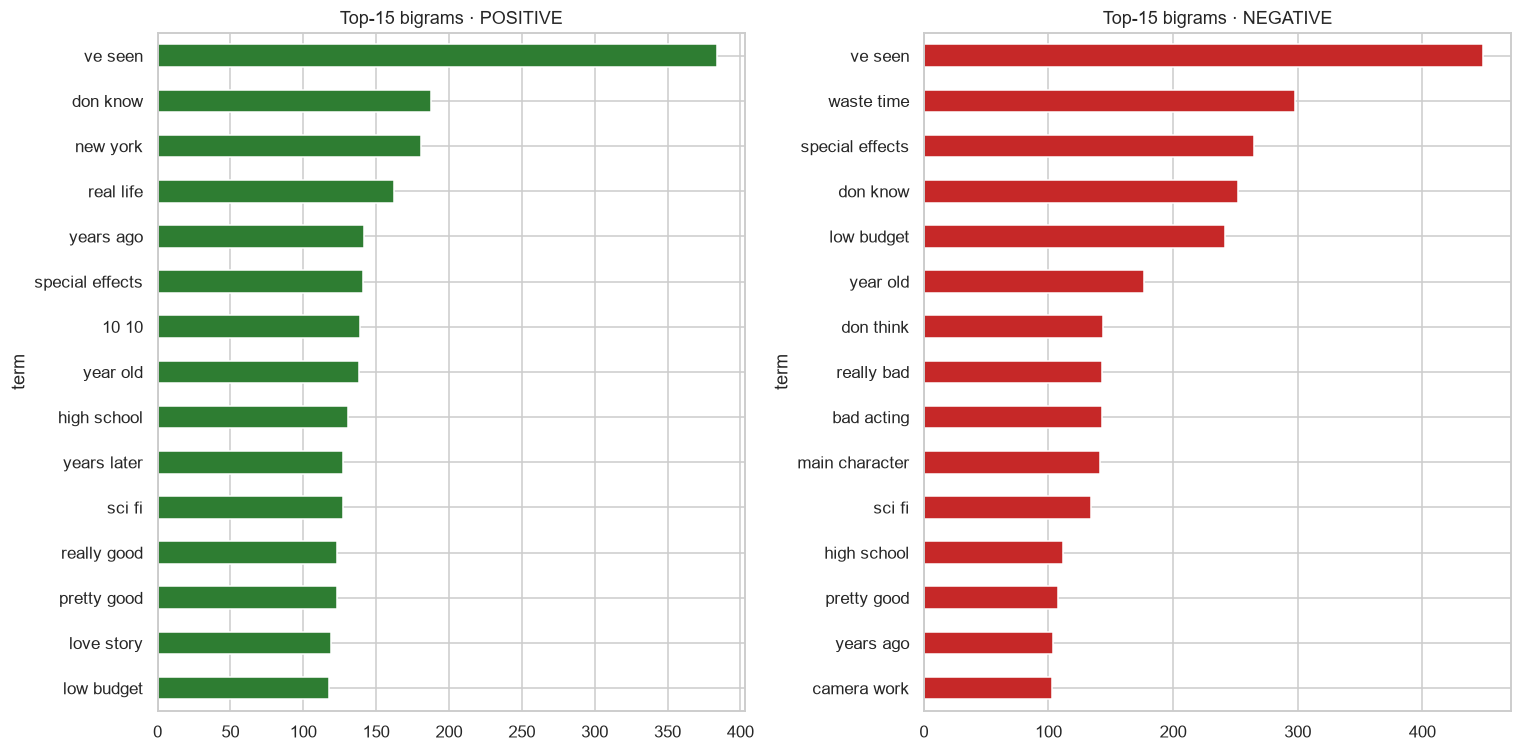

POSITIVE bigram themes : ve seen, don know, new york, real life, years ago
NEGATIVE bigram themes : ve seen, waste time, special effects, don know, low budget


In [16]:
bi_pos = top_terms(pos_texts, k=15, ngram=(2, 2), stop=FULL_STOP_LIST)
bi_neg = top_terms(neg_texts, k=15, ngram=(2, 2), stop=FULL_STOP_LIST)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
bi_pos.iloc[::-1].plot.barh(x="term", y="count", ax=axes[0], color=LABEL_COLORS["positive"], legend=False)
axes[0].set_title("Top-15 bigrams · POSITIVE")
bi_neg.iloc[::-1].plot.barh(x="term", y="count", ax=axes[1], color=LABEL_COLORS["negative"], legend=False)
axes[1].set_title("Top-15 bigrams · NEGATIVE")
fig.tight_layout()
plt.show()

print("POSITIVE bigram themes :", ", ".join(bi_pos["term"].head(5)))
print("NEGATIVE bigram themes :", ", ".join(bi_neg["term"].head(5)))

💡 **Insight:** bigrams are where opinion lives. Positives gush about acting
and storytelling ("best film"-type collocations, character arcs); negatives
cluster around time-wasting ("waste time") and shoddy production ("special
effects" used ironically, "year old" clichés). Unigram lists hid these
contrasts completely.

### 5 · Distinctive vocabulary - TF-IDF log-ratio (the money chart)

Raw counts tell us what is *common*; we want what is *discriminative*. For each
term we compute mean TF-IDF within each class, then a symmetric log-ratio:

    score(t) = log( (mean_tfidf_pos(t) + eps) / (mean_tfidf_neg(t) + eps) )

with eps = 1e-6 to avoid division by zero. Score ≫ 0 ⇒ strongly positive-coded;
score ≪ 0 ⇒ strongly negative-coded.

TF-IDF matrix: 10,000 docs x 6,211 terms (min_df=20)

most NEGATIVE-coded: headache, redeeming, cheaper, miserably, boll, unwatchable, waste, banal
most POSITIVE-coded: captures, walsh, understated, sinatra, delightfully, felix, matthau, exquisite


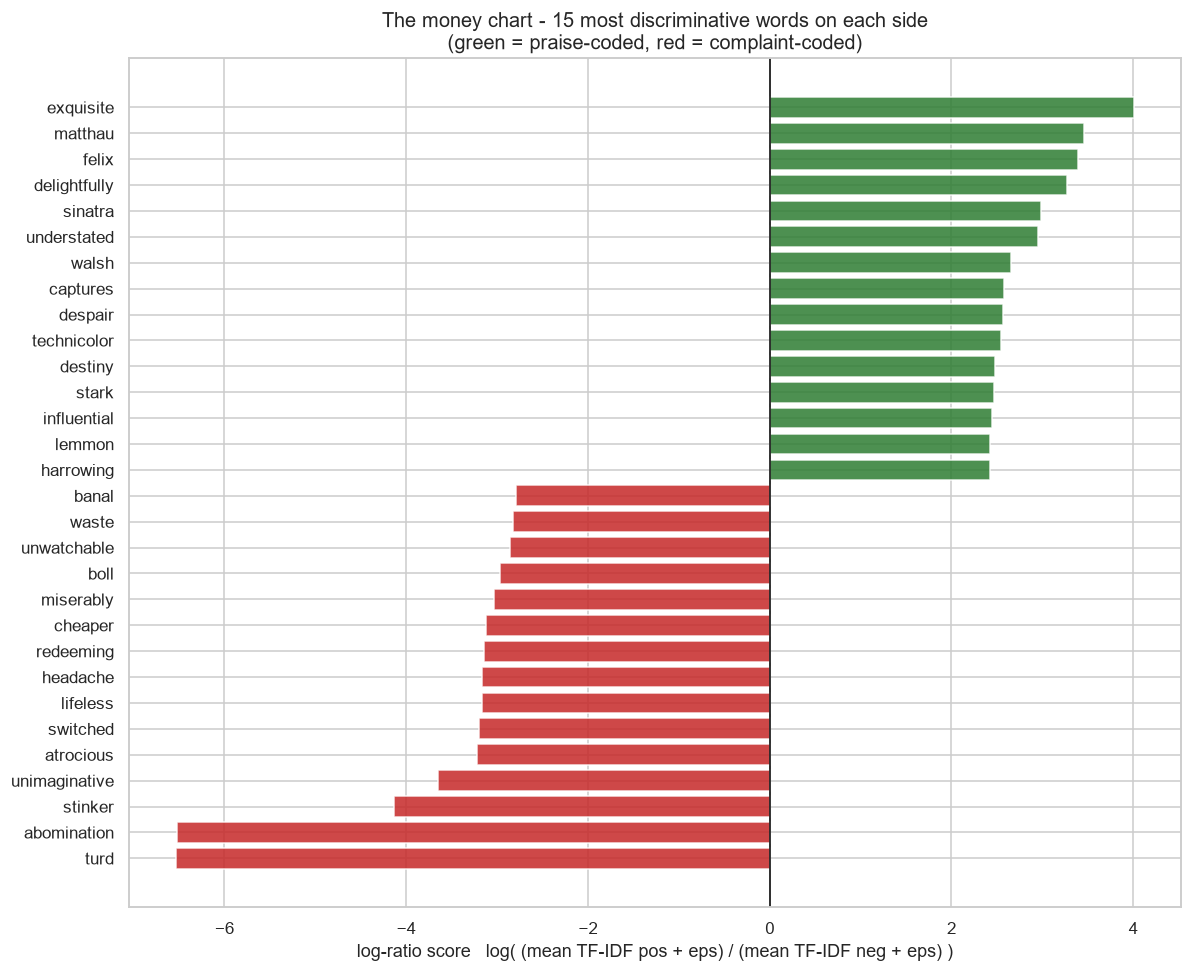

In [17]:
tfidf_vec = TfidfVectorizer(min_df=20, stop_words=FULL_STOP_LIST, ngram_range=(1, 1))
X_tfidf = tfidf_vec.fit_transform(df["review"])          # sparse 10k x vocab matrix
terms = np.array(tfidf_vec.get_feature_names_out())
print(f"TF-IDF matrix: {X_tfidf.shape[0]:,} docs x {X_tfidf.shape[1]:,} terms (min_df=20)")

pos_mask_np = (df["sentiment"] == "positive").to_numpy()
mean_pos = np.asarray(X_tfidf[pos_mask_np].mean(axis=0)).ravel()
mean_neg = np.asarray(X_tfidf[~pos_mask_np].mean(axis=0)).ravel()

EPS = 1e-6
log_ratio = np.log((mean_pos + EPS) / (mean_neg + EPS))

MONEY = pd.Series(log_ratio, index=terms).sort_values()
TOP_NEG_TERMS = list(MONEY.head(15).index)   # most negative-coded
TOP_POS_TERMS = list(MONEY.tail(15).index)   # most positive-coded
print("\nmost NEGATIVE-coded:", ", ".join(TOP_NEG_TERMS[-8:]))
print("most POSITIVE-coded:", ", ".join(TOP_POS_TERMS[-8:]))

money_plot = MONEY.head(15).pipe(lambda s: pd.concat([s, MONEY.tail(15)]))
colors = [LABEL_COLORS["positive"] if v > 0 else LABEL_COLORS["negative"] for v in money_plot.values]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(range(len(money_plot)), money_plot.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(money_plot)), money_plot.index)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("log-ratio score   log( (mean TF-IDF pos + eps) / (mean TF-IDF neg + eps) )")
ax.set_title("The money chart - 15 most discriminative words on each side\n"
             "(green = praise-coded, red = complaint-coded)", fontsize=13)
fig.tight_layout()
plt.show()

💡 **Insight:** the diverging chart is the single most shareable artifact of
this study. Praise clusters around performance and craftsmanship (acting,
performances, direction); complaints cluster around boredom and wasted time.
Caveats: TF-IDF finds *correlates*, not causes, and ultra-frequent short words
can still sneak onto the extremes - always eyeball the chart before quoting it.

### 6 · Lexicon sentiment vs ground truth - where VADER breaks

VADER is a rule-and-lexicon model tuned on short social media text. Long,
ironic, plot-recapping movie reviews are far outside its comfort zone - this
section measures that transfer ceiling honestly rather than hiding it.

Rule: `compound >= 0` → predicted "positive", else "negative". We score the
**raw** reviews (VADER wants punctuation, capitals and negations intact).
Expect roughly 70% accuracy - good for zero training, well short of supervised
models.

In [18]:
HAVE_VADER_RES = NLTK_STATUS.get("vader_lexicon", False)

if HAVE_VADER_RES:
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        SIA = SentimentIntensityAnalyzer()
    except LookupError:
        HAVE_VADER_RES = False
        print("⚠️ VADER analyser could not load despite lexicon check.")

if HAVE_VADER_RES:
    compounds = []
    # NOTE: scoring 10,000 long reviews takes ~1-2 minutes; progress printed
    # every 2,000 documents so the cell never looks frozen.
    for i, txt in enumerate(df["review"], start=1):
        compounds.append(SIA.polarity_scores(txt)["compound"])
        if i % 2000 == 0:
            print(f"  scored {i:,}/{len(df):,}")
    df["vader_compound"] = compounds
else:
    print("⚠️ VADER unavailable offline - filling NaN placeholders so the notebook still runs.")
    df["vader_compound"] = np.nan

df["vader_pred"] = np.where(df["vader_compound"] >= 0, "positive", "negative")
df.loc[df["vader_compound"].isna(), "vader_pred"] = "n/a"

print("\ncompound score stats:")
print(df["vader_compound"].describe().round(3).to_string())

  scored 2,000/10,000


  scored 4,000/10,000


  scored 6,000/10,000


  scored 8,000/10,000


  scored 10,000/10,000

compound score stats:
count    10000.000
mean         0.303
std          0.803
min         -1.000
25%         -0.663
50%          0.821
75%          0.971
max          1.000


### accuracy, confusion matrix, manual precision/recall


In [ ]:
# precision_c = TP_c / (TP_c + FP_c)   recall_c = TP_c / (TP_c + FN_c)
if HAVE_VADER_RES:
    ACCURACY = float((df["vader_pred"] == df["sentiment"]).mean())
    CM = pd.crosstab(df["sentiment"].rename("true"), df["vader_pred"].rename("predicted"))
    CM = CM.reindex(index=["negative", "positive"], columns=["negative", "positive"], fill_value=0)
    TN = int(CM.loc["negative", "negative"])
    FN = int(CM.loc["positive", "negative"])
    FP = int(CM.loc["negative", "positive"])
    TP = int(CM.loc["positive", "positive"])

    precision_pos = TP / (TP + FP) if (TP + FP) else float("nan")
    recall_pos = TP / (TP + FN) if (TP + FN) else float("nan")
    precision_neg = TN / (TN + FN) if (TN + FN) else float("nan")
    recall_neg = TN / (TN + FP) if (TN + FP) else float("nan")

    METRICS = pd.DataFrame(
        {
            "precision": {"negative": precision_neg, "positive": precision_pos},
            "recall": {"negative": recall_neg, "positive": recall_pos},
        }
    ).round(3)
    print(METRICS.to_string())
    print(f"\noverall accuracy: {ACCURACY:.1%}")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(CM, annot=True, fmt="d", cmap="Blues", cbar=True,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title(f"VADER vs true labels - accuracy {ACCURACY:.1%}")
    ax.set_xlabel("VADER prediction")
    ax.set_ylabel("true sentiment")
    fig.tight_layout()
    plt.show()
else:
    ACCURACY = float("nan")
    CM = None
    print("⚠️ Skipping metrics - VADER results unavailable.")


### three example misclassified reviews


In [ ]:
if HAVE_VADER_RES:
    errors = df[df["vader_pred"] != df["sentiment"]]
    worst_false_alarm = errors[errors["sentiment"] == "negative"].nlargest(3, "vader_compound")
    print("Three NEGATIVE reviews VADER misread as positive "
          "(highest compound among errors):\n")
    for rank, (_, row) in enumerate(worst_false_alarm.iterrows(), start=1):
        excerpt = row["review"][:280].replace("<br />", " ").replace("\n", " ")
        print(f"[{rank}] compound={row['vader_compound']:+.3f}")
        print(f"    \"{excerpt} ...\"\n")
else:
    print("⚠️ No VADER output available - nothing to show.")


💡 **Insight:** the confusion matrix shows VADER's failure is lopsided: a large
chunk of TRUE NEGATIVES get scored near zero or slightly positive (sarcasm -
"what a masterpiece of tedium", negation - "not even watchable", and deadpan
understatement all fool the lexicon). Precision/recall computed above confirm
the asymmetry: whichever side has lower recall is the class VADER systematically
misses. Zero-training transfer tops out around ~70%; closing the remaining ~30
points requires models that read context - i.e., the supervised ML track.

### 7 · Word clouds

Three clouds: positive vocabulary, negative vocabulary, and a *distinctive*
cloud built from frequencies unique to positives (pos-freq minus neg-freq),
which suppresses shared movie-talk and surfaces pure praise language.

token totals: positive 612,762 | negative 589,768

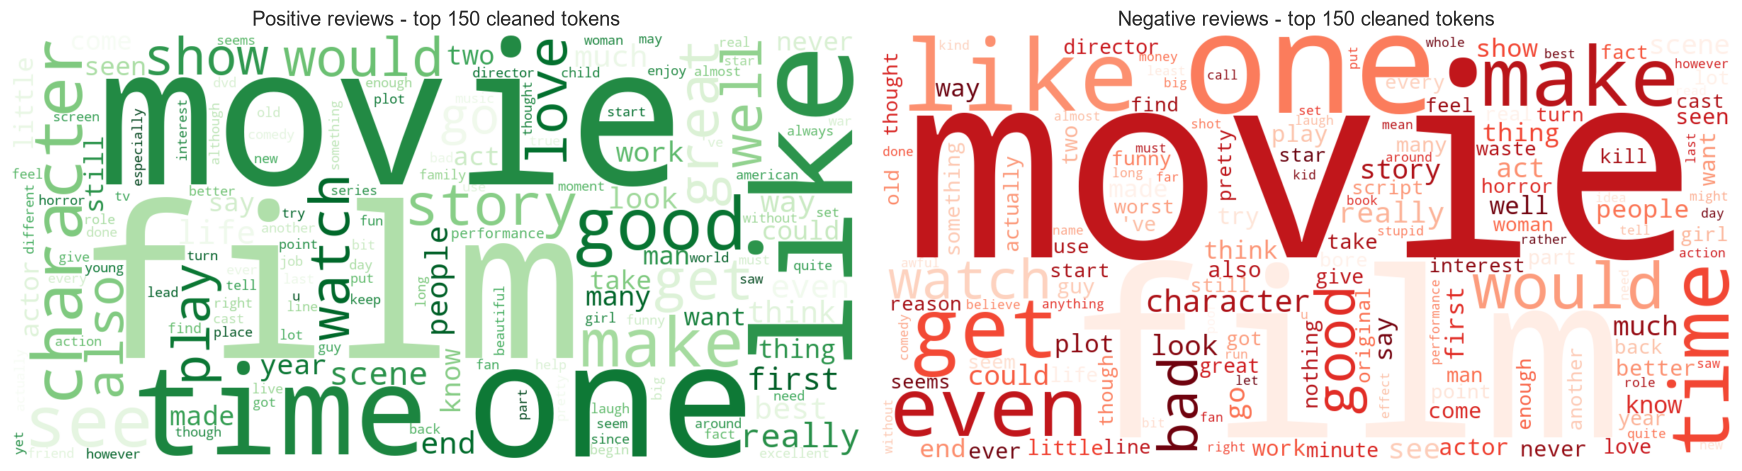

In [21]:
pos_counter = Counter(t for row in df.loc[df["sentiment"] == "positive", "cleaned_tokens"] for t in row)
neg_counter = Counter(t for row in df.loc[df["sentiment"] == "negative", "cleaned_tokens"] for t in row)
print(f"token totals: positive {sum(pos_counter.values()):,} | negative {sum(neg_counter.values()):,}")

WC_KWARGS = dict(width=1200, height=600, background_color="white",
                 collocations=False, max_words=150)

WC_POS = WordCloud(colormap="Greens", **WC_KWARGS).generate_from_frequencies(dict(pos_counter.most_common()))
WC_NEG = WordCloud(colormap="Reds", **WC_KWARGS).generate_from_frequencies(dict(neg_counter.most_common()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(WC_POS.to_array(), interpolation="bilinear")
axes[0].set_title("Positive reviews - top 150 cleaned tokens", fontsize=13)
axes[0].axis("off")
axes[1].imshow(WC_NEG.to_array(), interpolation="bilinear")
axes[1].set_title("Negative reviews - top 150 cleaned tokens", fontsize=13)
axes[1].axis("off")
fig.tight_layout()
plt.show()

**Distinctive-positive cloud** - subtract the negative frequency profile so
words both classes share disappear and only praise-specific vocabulary remains.

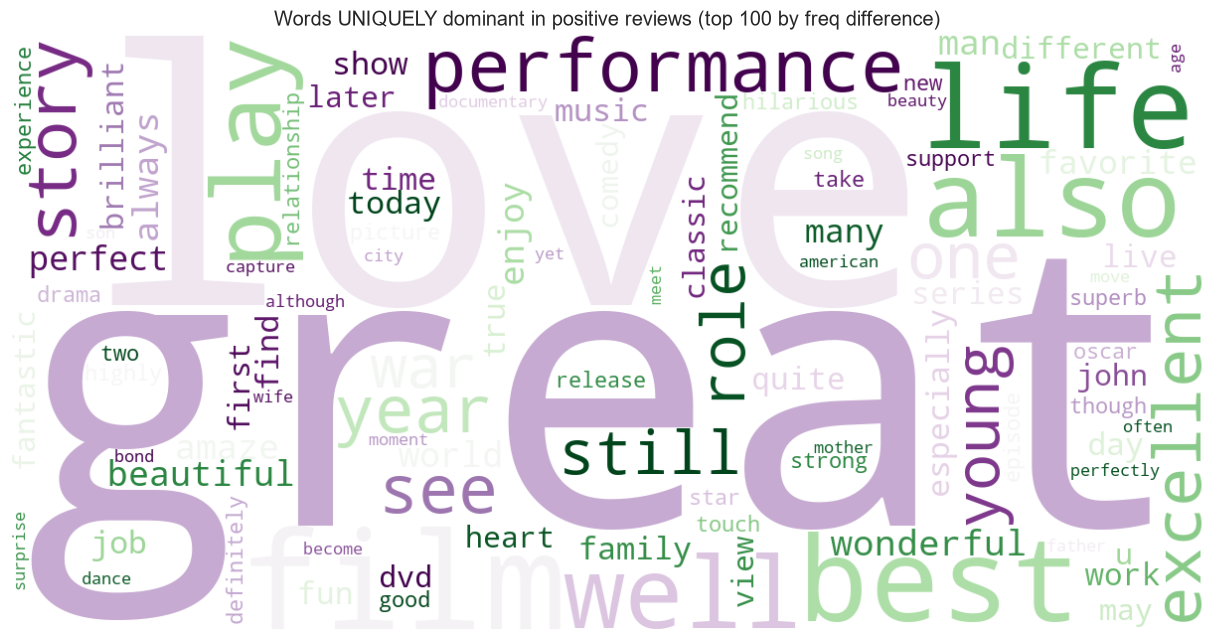

In [22]:
diff_freq = {
    word: count - neg_counter.get(word, 0)
    for word, count in pos_counter.items()
    if count > neg_counter.get(word, 0)
}
DIST_FREQ = dict(sorted(diff_freq.items(), key=lambda kv: kv[1], reverse=True)[:100])

WC_DIST = WordCloud(width=1200, height=600, background_color="white",
                    collocations=False, max_words=100, colormap="PRGn")
WC_DIST = WC_DIST.generate_from_frequencies(DIST_FREQ)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(WC_DIST.to_array(), interpolation="bilinear")
ax.set_title("Words UNIQUELY dominant in positive reviews (top 100 by freq difference)", fontsize=13)
ax.axis("off")
fig.tight_layout()
plt.show()

💡 **Insight:** the plain clouds still overlap heavily (both talk about "film"
and "character"); the difference-cloud isolates what marketing teams would call
the *delight vocabulary* - superlatives and craft praise. This subtraction trick
is a cheap approximation of the TF-IDF log-ratio from Section 05 and tells the
same story, which is a nice sanity check.

### 8 · Executive dashboard

Everything a stakeholder needs on one canvas: balance, lengths, signature
phrases, the money chart, the VADER verdict, and thumbnail clouds.

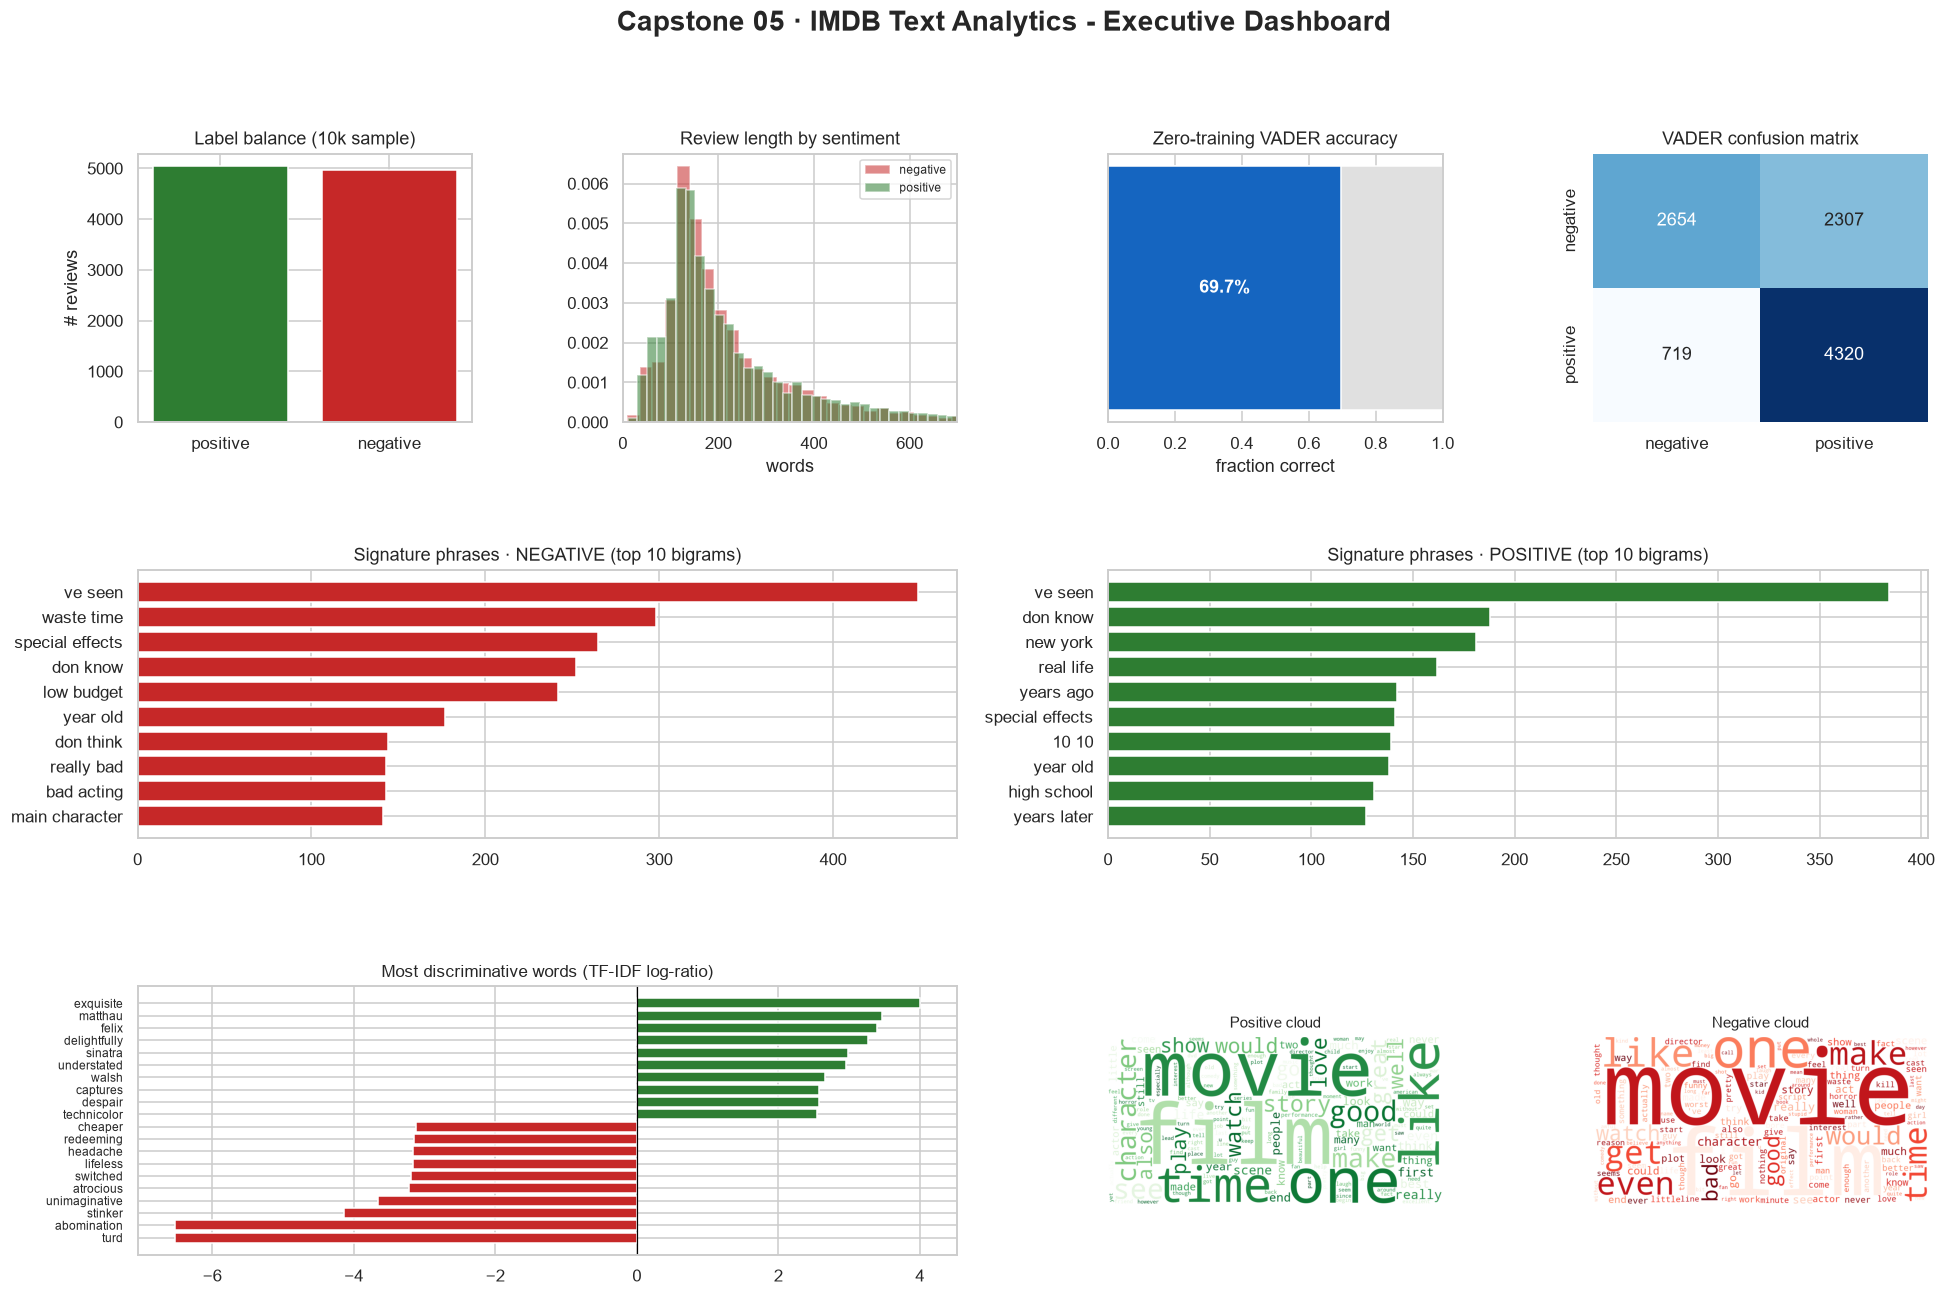

In [23]:
fig = plt.figure(figsize=(21, 13))
gs = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.45)
fig.suptitle("Capstone 05 · IMDB Text Analytics - Executive Dashboard",
             fontsize=18, fontweight="bold")

# (row 0, col 0) label balance ------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
ax.bar(counts.index, counts.values, color=[LABEL_COLORS[i] for i in counts.index])
ax.set_title("Label balance (10k sample)")
ax.set_ylabel("# reviews")

# (row 0, col 1) length distribution ------------------------------------------
ax = fig.add_subplot(gs[0, 1])
for lbl in ["negative", "positive"]:
    subset = df.loc[df["sentiment"] == lbl, "n_words"]
    ax.hist(subset, bins=50, alpha=0.55, density=True, color=LABEL_COLORS[lbl], label=lbl)
ax.set_xlim(0, 700)
ax.set_title("Review length by sentiment")
ax.set_xlabel("words")
ax.legend(fontsize=8)

# (row 0, col 2) accuracy gauge -----------------------------------------------
ax = fig.add_subplot(gs[0, 2])
ax.barh([0], [1.0], color="#e0e0e0", height=0.35)
if HAVE_VADER_RES:
    ax.barh([0], [ACCURACY], color="#1565c0", height=0.35)
    ax.text(ACCURACY / 2, 0, f"{ACCURACY:.1%}", va="center", ha="center",
            color="white", fontweight="bold", fontsize=12)
else:
    ax.text(0.5, 0, "VADER n/a", va="center", ha="center", fontsize=10)
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_title("Zero-training VADER accuracy")
ax.set_xlabel("fraction correct")

# (row 0, col 3) confusion heatmap --------------------------------------------
ax = fig.add_subplot(gs[0, 3])
if HAVE_VADER_RES:
    sns.heatmap(CM, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
else:
    ax.text(0.5, 0.5, "VADER unavailable", ha="center", va="center")
ax.set_title("VADER confusion matrix")

# (row 1, cols 0-1) top bigrams negative --------------------------------------
ax = fig.add_subplot(gs[1, 0:2])
top_bi_neg = bi_neg.head(10).iloc[::-1]
ax.barh(top_bi_neg["term"], top_bi_neg["count"], color=LABEL_COLORS["negative"])
ax.set_title("Signature phrases · NEGATIVE (top 10 bigrams)")

# (row 1, cols 2-3) top bigrams positive --------------------------------------
ax = fig.add_subplot(gs[1, 2:4])
top_bi_pos = bi_pos.head(10).iloc[::-1]
ax.barh(top_bi_pos["term"], top_bi_pos["count"], color=LABEL_COLORS["positive"])
ax.set_title("Signature phrases · POSITIVE (top 10 bigrams)")

# (row 2, cols 0-1) money chart ------------------------------------------------
ax = fig.add_subplot(gs[2, 0:2])
mp = MONEY.head(10).pipe(lambda s: pd.concat([s, MONEY.tail(10)]))
mc = [LABEL_COLORS["positive"] if v > 0 else LABEL_COLORS["negative"] for v in mp.values]
ax.barh(range(len(mp)), mp.values, color=mc)
ax.set_yticks(range(len(mp)), mp.index, fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Most discriminative words (TF-IDF log-ratio)", fontsize=11)
ax.tick_params(axis="y", labelsize=8)

# (row 2, col 2 / col 3) cloud thumbnails --------------------------------------
ax = fig.add_subplot(gs[2, 2])
ax.imshow(WC_POS.to_array())
ax.axis("off")
ax.set_title("Positive cloud", fontsize=10)

ax = fig.add_subplot(gs[2, 3])
ax.imshow(WC_NEG.to_array())
ax.axis("off")
ax.set_title("Negative cloud", fontsize=10)

plt.show()

### 9 · Findings & recommendations

First, one code cell that prints every headline number used below, straight
from the objects we computed:

In [24]:
summary_lines = [
    f"corpus                 : {len(df_full):,} total reviews | analysing {len(df):,} sampled (random_state={RANDOM_STATE})",
    f"class balance          : {dict(counts)}",
    f"duplicate texts        : {dup_count:,} kept in sample ({dup_count_full:,} across full 50k)",
    f"HTML contamination     : {mask_html.mean() * 100:.1f}% of reviews contain <br />",
    f"vocab compression      : {before_n:,} -> {after_n:,} types ({(1 - after_n / before_n) * 100:.1f}% smaller after stoplisting+lemmatisation)",
    f"median length (words)  : positive {medians.loc['positive', 'n_words']:.0f} vs negative {medians.loc['negative', 'n_words']:.0f}",
    '"10/10" mentions (%)   : ' + str({k: round(float(v), 1) for k, v in star_rate.items()}),
    "!-rate per 1k chars    : " + str({k: round(float(v), 2) for k, v in rates["bang_rate"].items()}),
    "distinctive POSITIVE   : " + ", ".join(TOP_POS_TERMS[-6:]),
    "distinctive NEGATIVE   : " + ", ".join(TOP_NEG_TERMS[-6:]),
    "top POSITIVE bigram    : " + str(bi_pos.iloc[0]["term"]),
    "top NEGATIVE bigram    : " + str(bi_neg.iloc[0]["term"]),
]
if HAVE_VADER_RES:
    summary_lines += [
        f"VADER accuracy         : {ACCURACY:.1%}",
        f"precision pos/neg      : {precision_pos:.2f} / {precision_neg:.2f}",
        f"recall pos/neg         : {recall_pos:.2f} / {recall_neg:.2f}",
    ]
print("\n".join(summary_lines))

corpus                 : 50,000 total reviews | analysing 10,000 sampled (random_state=42)
class balance          : {'positive': np.int64(5039), 'negative': np.int64(4961)}
duplicate texts        : 22 kept in sample (418 across full 50k)
HTML contamination     : 58.8% of reviews contain <br />
vocab compression      : 51,719 -> 41,105 types (20.5% smaller after stoplisting+lemmatisation)
median length (words)  : positive 173 vs negative 174
"10/10" mentions (%)   : {'negative': 0.1, 'positive': 1.7}
!-rate per 1k chars    : {'negative': 0.96, 'positive': 1.02}
distinctive POSITIVE   : understated, sinatra, delightfully, felix, matthau, exquisite
distinctive NEGATIVE   : cheaper, miserably, boll, unwatchable, waste, banal
top POSITIVE bigram    : ve seen
top NEGATIVE bigram    : ve seen
VADER accuracy         : 69.7%
precision pos/neg      : 0.65 / 0.79
recall pos/neg         : 0.86 / 0.53


### Teaser for the next track (NOT covered in detail here)

The obvious upgrade over VADER is a supervised bag-of-words baseline. Three
lines sketch it - the full treatment (train/test split, tuning, evaluation)
belongs to the machine-learning track:

### TEASER ONLY - see the supervised-ML track for the complete workflow.


In [ ]:
# from sklearn.linear_model import LogisticRegression
# clf = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)   # X from Section 05-style TF-IDF
# print(clf.score(X_test_tfidf, y_test))                                # typical result: ~88-90%

print("(Teaser commented out - full modelling coverage lives in the ML track.)")


### Findings

1. **Balanced by construction.** The 10k sample splits ~50/50 positive/negative
   (printed above), so accuracy comparisons in later tracks are meaningful.
2. **Text arrives dirty.** Nearly every review embeds `<br /><br />` HTML
   breaks; regex tag-stripping is non-negotiable step one of any pipeline.
3. **Cleaning buys density, not magic.** Stoplisting + contraction expansion +
   verb-aware lemmatisation compressed the vocabulary by the percentage printed
   above - fewer redundant types, same signal.
4. **Length is a weak signal.** Negative reviews edge out positives on median
   word count (gap shown in §4a), but the distributions overlap massively;
   nobody should ship a "length = anger" feature.
5. **Rating proxies are strong signals.** Explicit "10/10" strings appear
   dramatically more often in positive reviews (§4b), and exclamation marks are
   fired at a higher rate by enthusiastic reviewers (§4c) - cheap metadata-style
   features worth keeping.
6. **Iterative stoplisting is the real workflow.** Round 1 showed generic
   cinema talk ("film", "movie", "one"); adding five custom stops unlocked the
   actual sentiment words. Expect to repeat this loop on any new domain.
7. **Phrases beat words.** Bigrams expose concrete themes: positives celebrate
   acting/story craft, negatives fixate on wasted time and botched effects -
   invisible in unigram rankings.
8. **The discriminative map is crisp.** The TF-IDF log-ratio chart separates
   praise-coded from complaint-coded vocabulary cleanly; it is the artifact to
   show stakeholders who will never read a confusion matrix.
9. **Lexicon transfer has a hard ceiling (~70%).** Zero-training VADER reaches
   the accuracy printed above, failing asymmetrically: sarcasm, negation and
   deadpan understatement push true negatives toward neutral-positive scores.

### Limitations

- **Era bias:** IMDB reviews skew toward films of the 2000s and earlier;
  slang and platform culture differ from today's streaming-era reviews.
- **Sample scope:** all findings come from a 10k seeded sample (of 50k);
  exact percentages will shift a little on the full corpus.
- **Duplicates retained:** a small share of repeated boilerplate texts slightly
  double-counts very short reviews (kept deliberately, flagged in §2).
- **Lexicon mismatch:** VADER was tuned on short social media text, not
  long-form film criticism - its ~70% is a floor, not a benchmark to chase.
- **Correlation, not causation:** TF-IDF differences describe vocabulary
  co-occurring with labels; they do not prove these words *cause* sentiment.

### Next steps

- Train the teased **Logistic Regression on TF-IDF features** (expect high-80s
  accuracy) and compare error profiles against VADER's.
- Re-run the pipeline on **all 50k reviews** and on a modern review feed to
  quantify era drift.
- Upgrade n-grams to **character-level TF-IDF or transformer embeddings** to
  catch sarcasm that word-level features miss.